In [28]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import pandas as pd
import seaborn as sns
import glob
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [29]:
normal_path = r"C:\Users\Nandy\Downloads\val\normal"
opacity_path = r"C:\Users\Nandy\Downloads\val\opacity"

In [50]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

In [51]:
opacity_images = (
    glob.glob(opacity_path + r"\*.png") +
    glob.glob(opacity_path + r"\*.jpg") +
    glob.glob(opacity_path + r"\*.jpeg")
)

print("Number of opacity images:", len(opacity_images))

normal_images = (
    glob.glob(normal_path + r"\*.png") +
    glob.glob(normal_path + r"\*.jpg") +
    glob.glob(normal_path + r"\*.jpeg")
)

print("Number of normal images:", len(normal_images))

Number of opacity images: 773
Number of normal images: 267


In [52]:
opacity_df = pd.DataFrame({
    "filename": opacity_images,
    "label": 1
})

normal_df = pd.DataFrame({
    "filename": normal_images,
    "label": 0
})

df = pd.concat(
    [opacity_df, normal_df],
    ignore_index=True
)

In [53]:
print("\nDataset shape:")
print(df.shape)

print("\nDataset head:")
print(df.head())

print("\nDataset tail:")
print(df.tail())

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape:
(1040, 2)

Dataset head:
                                            filename  label
0  C:\Users\Nandy\Downloads\val\opacity\person139...      1
1  C:\Users\Nandy\Downloads\val\opacity\person139...      1
2  C:\Users\Nandy\Downloads\val\opacity\person139...      1
3  C:\Users\Nandy\Downloads\val\opacity\person139...      1
4  C:\Users\Nandy\Downloads\val\opacity\person139...      1

Dataset tail:
                                               filename  label
1035  C:\Users\Nandy\Downloads\val\normal\NORMAL2-IM...      0
1036  C:\Users\Nandy\Downloads\val\normal\NORMAL2-IM...      0
1037  C:\Users\Nandy\Downloads\val\normal\NORMAL2-IM...      0
1038  C:\Users\Nandy\Downloads\val\normal\NORMAL2-IM...      0
1039  C:\Users\Nandy\Downloads\val\normal\NORMAL2-IM...      0

Missing values:
filename    0
label       0
dtype: int64


In [54]:
print("\nClass Distribution:")
print(df["label"].value_counts())

print("\nClass Names:")
print(
    df["label"].value_counts().rename(
        index={
            0: "NORMAL",
            1: "OPACITY"
        }
    )
)


Class Distribution:
label
1    773
0    267
Name: count, dtype: int64

Class Names:
label
OPACITY    773
NORMAL     267
Name: count, dtype: int64


In [56]:
# SHUFFLE DATA

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("\nTraining Images:", len(train_df))
print("Testing Images:", len(test_df))


Training Images: 832
Testing Images: 208


In [57]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20
)

In [58]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [59]:
# TRAINING DATA GENERATOR

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training",
    shuffle=True
)

Found 666 validated image filenames.


In [60]:
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation",
    shuffle=False
)

Found 166 validated image filenames.


In [61]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 208 validated image filenames.


In [62]:
print("\nTraining Samples:", train_generator.samples)
print("Validation Samples:", validation_generator.samples)
print("Testing Samples:", test_generator.samples)


Training Samples: 666
Validation Samples: 166
Testing Samples: 208


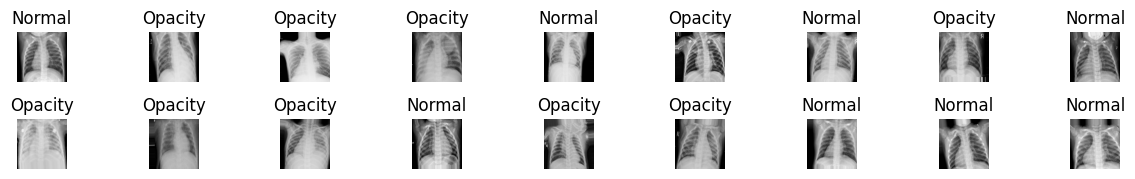

In [67]:
images,labels=next(train_generator)
plt.figure(figsize=(12,8))
for i in range(18):
    plt.subplot(9,9,i+1)
    plt.imshow(images[i])
    if labels[i]==1:
        plt.title("Opacity")
    else:
        plt.title("Normal")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(150,150,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )
])

C:\microsoft visual studio\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)

Epoch 1/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.6772 - loss: 0.6843 - val_accuracy: 0.7470 - val_loss: 0.5664
Epoch 2/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.7417 - loss: 0.5827 - val_accuracy: 0.7470 - val_loss: 0.5711
Epoch 3/3
21/21 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.7417 - loss: 0.5872 - val_accuracy: 0.7470 - val_loss: 0.5309


In [66]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("TEST RESULTS")
print("TEST Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7452 - loss: 0.5359
TEST RESULTS
TEST Loss: 0.5358706712722778
Test Accuracy: 0.745192289352417


In [68]:
test_generator.reset()
predictions = model.predict(test_generator)

predicted_classes = (predictions >= 0.5).astype(int).flatten()

image_path = opacity_images[0]
print("\nImage Used For Prediction:")
print(image_path)

7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step

Image Used For Prediction:
C:\Users\Nandy\Downloads\val\opacity\person1397_virus_2400.jpeg


In [69]:
img = tf.keras.utils.load_img(image_path,
    target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step

Prediction Probability: 0.5065056
Prediction: Opacity


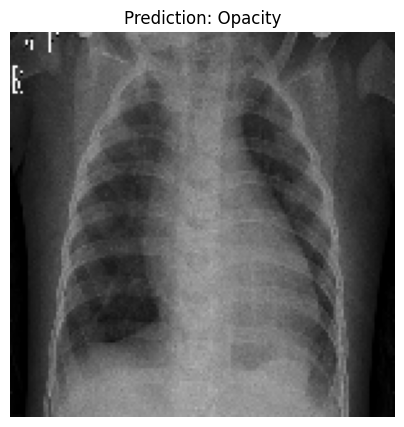

In [71]:
img_array = img_array / 255.0
prediction = model.predict(img_array)
probability = prediction[0][0]
print("\nPrediction Probability:",probability)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
if probability >= 0.5:
    print("Prediction: Opacity")
    plt.title("Prediction: Opacity")
else:
    print("Prediction: NORMAL")
    plt.title("Prediction: NORMAL")
plt.show()